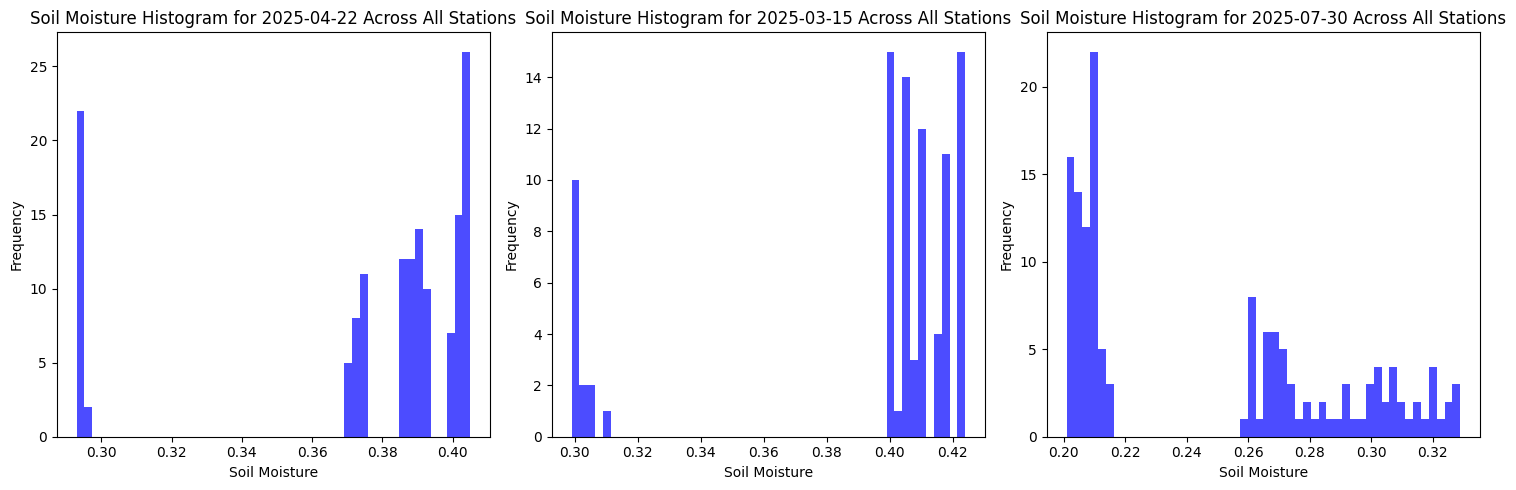

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

# Get all STM files
file_paths = glob.glob('TERENO_TERENO_Schoeneseiffen_sm_*.stm')

# Load one file to get unique dates
sample_df = pd.read_csv(file_paths[0], sep=r'\s+', skiprows=1, header=None, names=['date', 'time', 'soil_moisture', 'flag', 'source'])
sample_df['datetime'] = pd.to_datetime(sample_df['date'] + ' ' + sample_df['time'], format='%Y/%m/%d %H:%M')
sample_df.set_index('datetime', inplace=True)
sample_df = sample_df[sample_df['flag'] == 'G']
unique_dates = np.unique(sample_df.index.date)

# Select three random dates
np.random.seed(42)  # For reproducibility
selected_dates = np.random.choice(unique_dates, 3, replace=False)

# Collect data for each selected date across all files
data_per_date = {date: [] for date in selected_dates}

for file_path in file_paths:
    # Load the data
    df = pd.read_csv(file_path, sep=r'\s+', skiprows=1, header=None, names=['date', 'time', 'soil_moisture', 'flag', 'source'])
    
    # Combine date and time
    df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], format='%Y/%m/%d %H:%M')
    df.set_index('datetime', inplace=True)
    
    # Filter valid data
    df = df[df['flag'] == 'G']
    
    # Collect data for selected dates
    for date in selected_dates:
        mask = df.index.date == date
        daily_data = df[mask]['soil_moisture']
        data_per_date[date].extend(daily_data.tolist())

# Plot histograms for each selected date
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, date in enumerate(selected_dates):
    axes[i].hist(data_per_date[date], bins=50, alpha=0.7, color='blue')
    axes[i].set_title(f'Soil Moisture Histogram for {date} Across All Stations')
    axes[i].set_xlabel('Soil Moisture')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

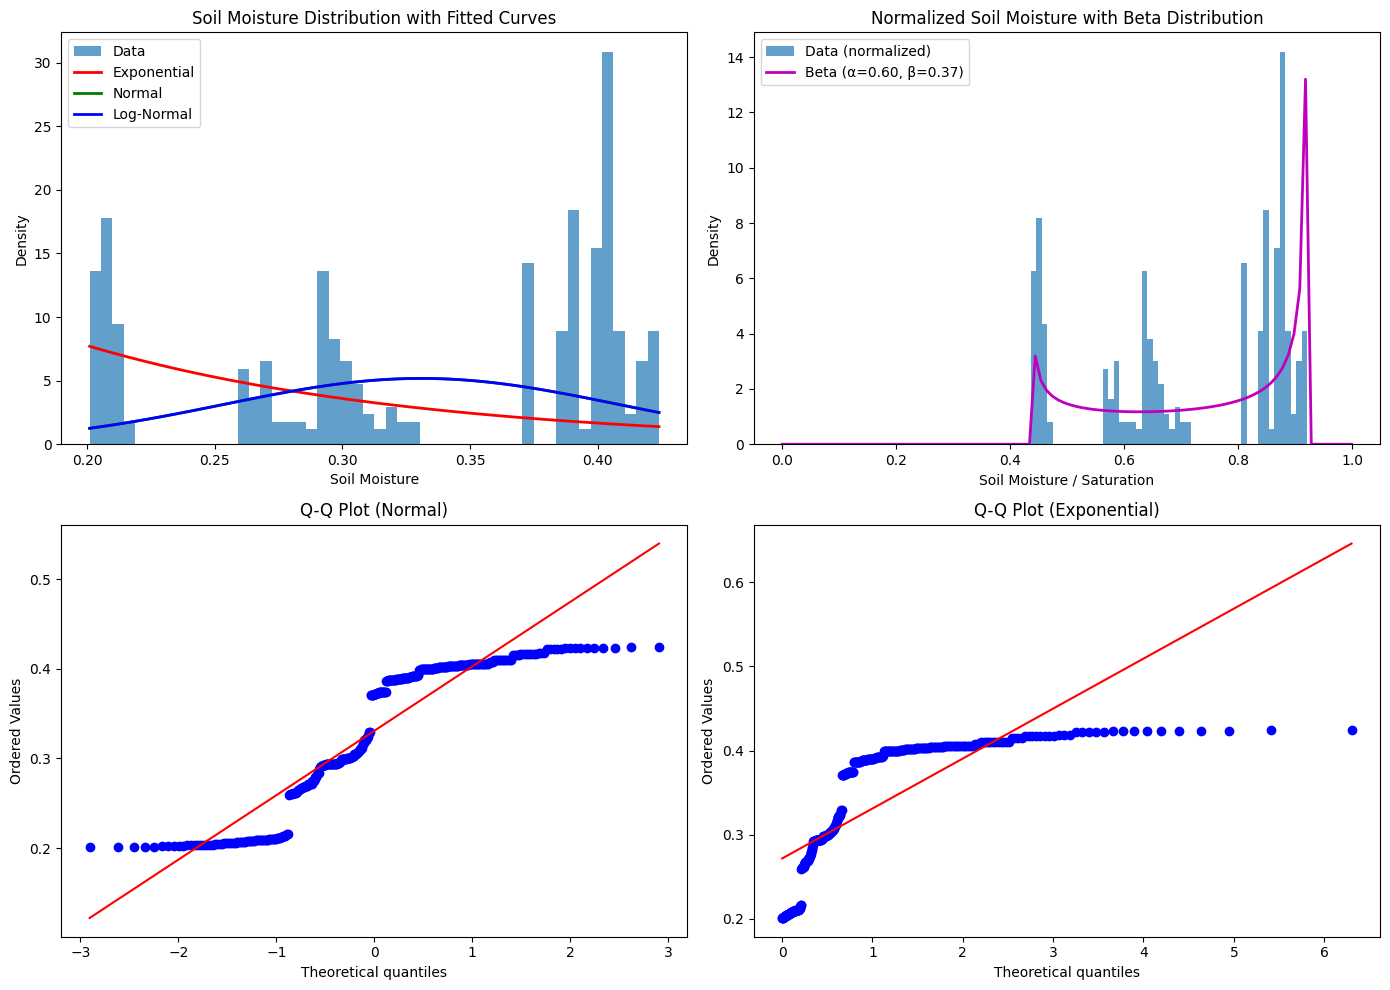

=== Kolmogorov-Smirnov Tests ===
Exponential: statistic=0.2458, p-value=1.3500e-20
Normal: statistic=0.2151, p-value=7.9341e-16
Log-Normal: statistic=0.2151, p-value=7.9335e-16
Beta (normalized): statistic=0.1952, p-value=4.2825e-13

(Plus la p-value est élevée, meilleur est le fit)


In [13]:
from scipy import stats
from scipy.stats import expon, norm, lognorm, beta

# Combine all data for analysis
all_data = np.concatenate([data_per_date[date] for date in selected_dates])

# Normalize data to [0, 1] for beta distribution (using saturation value from static file)
saturation = 0.46
all_data_normalized = all_data / saturation
all_data_normalized = np.clip(all_data_normalized, 0.001, 0.999)  # Avoid edge issues for beta

# Fit different distributions
# Exponential
exp_params = expon.fit(all_data)
# Normal
norm_params = norm.fit(all_data)
# Log-normal
lognorm_params = lognorm.fit(all_data)
# Beta (on normalized data)
beta_params = beta.fit(all_data_normalized)

# Create x values for plotting
x = np.linspace(min(all_data), max(all_data), 100)
x_norm = np.linspace(0.001, 0.999, 100)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram with fitted distributions
ax = axes[0, 0]
ax.hist(all_data, bins=50, density=True, alpha=0.7, label='Data')
ax.plot(x, expon.pdf(x, *exp_params), 'r-', lw=2, label=f'Exponential')
ax.plot(x, norm.pdf(x, *norm_params), 'g-', lw=2, label=f'Normal')
ax.plot(x, lognorm.pdf(x, *lognorm_params), 'b-', lw=2, label=f'Log-Normal')
ax.set_title('Soil Moisture Distribution with Fitted Curves')
ax.set_xlabel('Soil Moisture')
ax.set_ylabel('Density')
ax.legend()

# Beta distribution on normalized data
ax = axes[0, 1]
ax.hist(all_data_normalized, bins=50, density=True, alpha=0.7, label='Data (normalized)')
ax.plot(x_norm, beta.pdf(x_norm, *beta_params), 'm-', lw=2, label=f'Beta (α={beta_params[0]:.2f}, β={beta_params[1]:.2f})')
ax.set_title('Normalized Soil Moisture with Beta Distribution')
ax.set_xlabel('Soil Moisture / Saturation')
ax.set_ylabel('Density')
ax.legend()

# Q-Q plots
ax = axes[1, 0]
stats.probplot(all_data, dist="norm", plot=ax)
ax.set_title('Q-Q Plot (Normal)')

ax = axes[1, 1]
stats.probplot(all_data, dist="expon", plot=ax)
ax.set_title('Q-Q Plot (Exponential)')

plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov tests
print("=== Kolmogorov-Smirnov Tests ===")
print(f"Exponential: statistic={stats.kstest(all_data, 'expon', exp_params).statistic:.4f}, p-value={stats.kstest(all_data, 'expon', exp_params).pvalue:.4e}")
print(f"Normal: statistic={stats.kstest(all_data, 'norm', norm_params).statistic:.4f}, p-value={stats.kstest(all_data, 'norm', norm_params).pvalue:.4e}")
print(f"Log-Normal: statistic={stats.kstest(all_data, 'lognorm', lognorm_params).statistic:.4f}, p-value={stats.kstest(all_data, 'lognorm', lognorm_params).pvalue:.4e}")
print(f"Beta (normalized): statistic={stats.kstest(all_data_normalized, 'beta', beta_params).statistic:.4f}, p-value={stats.kstest(all_data_normalized, 'beta', beta_params).pvalue:.4e}")
print("\n(Plus la p-value est élevée, meilleur est le fit)")

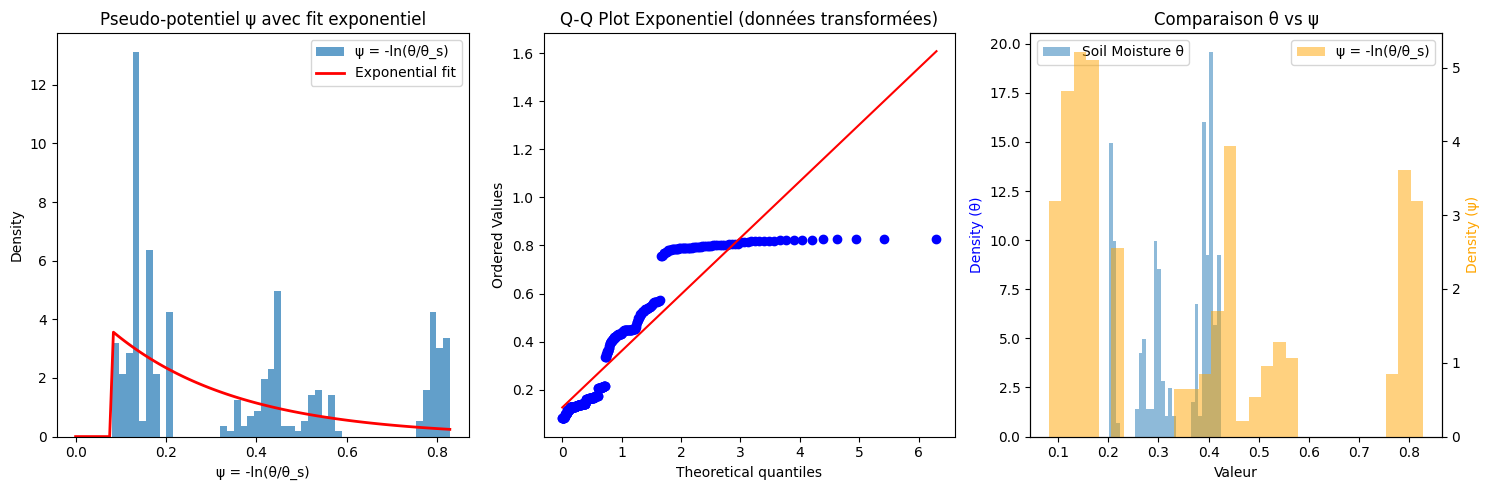

=== Test KS pour la distribution exponentielle sur ψ ===
Statistic: 0.1664
P-value: 1.2975e-09

Interprétation: ❌ Ne suit pas parfaitement une exponentielle


In [14]:
# Transformation vers pseudo-potentiel (devrait suivre une exponentielle)
# ψ = -ln(θ / θ_s) où θ = soil moisture et θ_s = saturation

saturation = 0.46

# Éviter les valeurs nulles ou négatives pour le log
all_data_clipped = np.clip(all_data, 0.001, saturation - 0.001)

# Transformation
psi = -np.log(all_data_clipped / saturation)

# Fit exponentielle sur les données transformées
exp_params_psi = expon.fit(psi)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogramme des données transformées avec fit exponentiel
ax = axes[0]
ax.hist(psi, bins=50, density=True, alpha=0.7, label='ψ = -ln(θ/θ_s)')
x_psi = np.linspace(0, max(psi), 100)
ax.plot(x_psi, expon.pdf(x_psi, *exp_params_psi), 'r-', lw=2, label=f'Exponential fit')
ax.set_title('Pseudo-potentiel ψ avec fit exponentiel')
ax.set_xlabel('ψ = -ln(θ/θ_s)')
ax.set_ylabel('Density')
ax.legend()

# Q-Q plot pour exponentielle
ax = axes[1]
stats.probplot(psi, dist="expon", plot=ax)
ax.set_title('Q-Q Plot Exponentiel (données transformées)')

# Comparaison avant/après transformation
ax = axes[2]
ax.hist(all_data, bins=30, density=True, alpha=0.5, label='Soil Moisture θ')
ax2 = ax.twinx()
ax2.hist(psi, bins=30, density=True, alpha=0.5, color='orange', label='ψ = -ln(θ/θ_s)')
ax.set_xlabel('Valeur')
ax.set_ylabel('Density (θ)', color='blue')
ax2.set_ylabel('Density (ψ)', color='orange')
ax.set_title('Comparaison θ vs ψ')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Test KS pour exponentielle
ks_stat, ks_pvalue = stats.kstest(psi, 'expon', exp_params_psi)
print(f"=== Test KS pour la distribution exponentielle sur ψ ===")
print(f"Statistic: {ks_stat:.4f}")
print(f"P-value: {ks_pvalue:.4e}")
print(f"\nInterprétation: {'✅ Bon fit exponentiel!' if ks_pvalue > 0.05 else '❌ Ne suit pas parfaitement une exponentielle'}")